In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa


In [ ]:
# ------------------ 1) 読み込み ------------------
WAV = "/root/MedWhisper/202502/右後ろ_1回目.wav"
y, sr = librosa.load(WAV, sr=16000, mono=True)

# ------------------ 2) 事前フィルタ（軽め） ------------------
# 100 Hz ハイパスで環境ノイズを軽減（過度にやらない）
from scipy.signal import butter, filtfilt
b_hp, a_hp = butter(2, 100/(sr/2), btype='highpass')
y = filtfilt(b_hp, a_hp, y)


SyntaxError: unterminated string literal (detected at line 2) (160651208.py, line 2)

In [8]:
# ------------------ 3) F0 推定（librosa.yin） ------------------
# 25 ms 窓, 10 ms ホップ相当
frame_length = int(0.025 * sr)
hop_length   = int(0.010 * sr)

In [9]:
# 人声のF0レンジ（Hz）: 70〜350（成人男女の概ね）
f0 = librosa.yin(y, fmin=70, fmax=350, sr=sr, frame_length=frame_length, hop_length=hop_length)
time = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=hop_length)

# 簡易エネルギー（RMS）で無音除外
rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length, center=True).flatten()
rms_thresh = np.quantile(rms, 0.3)  # 下位30%を無音寄りとみなす
voiced = (~np.isnan(f0)) & (rms > rms_thresh)


/tmp/ipykernel_7559/273494517.py:2: UserWarning: With fmin=70.000, sr=16000 and frame_length=400, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=80.000 or frame_length=459.
  f0 = librosa.yin(y, fmin=70, fmax=350, sr=sr, frame_length=frame_length, hop_length=hop_length)


In [10]:
# ------------------ 4) 冒頭30秒の「主話者」F0レンジ推定 ------------------
first_T = 30.0
head_mask = (time <= first_T) & voiced
f0_head = f0[head_mask]

In [12]:
# log-F0 にして KMeans(2) → フレーム数が多いクラスタを “主話者” と仮定
from sklearn.cluster import KMeans
logf0_head = np.log(f0_head).reshape(-1,1) if len(f0_head)>0 else np.array([[np.log(150.0)]])
n_clusters = 2 if len(logf0_head) >= 10 else 1
if n_clusters == 2:
    km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(logf0_head)
    labels, counts = np.unique(km.labels_, return_counts=True)
    main_label = labels[np.argmax(counts)]
    mu = km.cluster_centers_[main_label, 0]
    sigma = np.std(logf0_head[km.labels_==main_label])
else:
    mu = float(np.mean(logf0_head))
    sigma = float(np.std(logf0_head)) if np.std(logf0_head)>0 else 0.1

# σが極端に小さいと数値不安定 → 下限を設定
sigma = max(sigma, 0.08)

# ------------------ 5) 全体で“主話者マッチ度”を算出 ------------------
# ガウス尤度に近い形: score = exp(-0.5 * ((logf0 - mu)/sigma)^2), 無声は0
logf0_full = np.log(np.clip(f0, 1e-6, None))
z = (logf0_full - mu)/sigma
score = np.exp(-0.5 * (z**2))
score[~voiced] = 0.0

# 平滑化（移動平均 0.5秒）
win = int(0.5 / (hop_length/sr))
if win > 1:
    kernel = np.ones(win)/win
    score_smooth = np.convolve(score, kernel, mode='same')
else:
    score_smooth = score.copy()

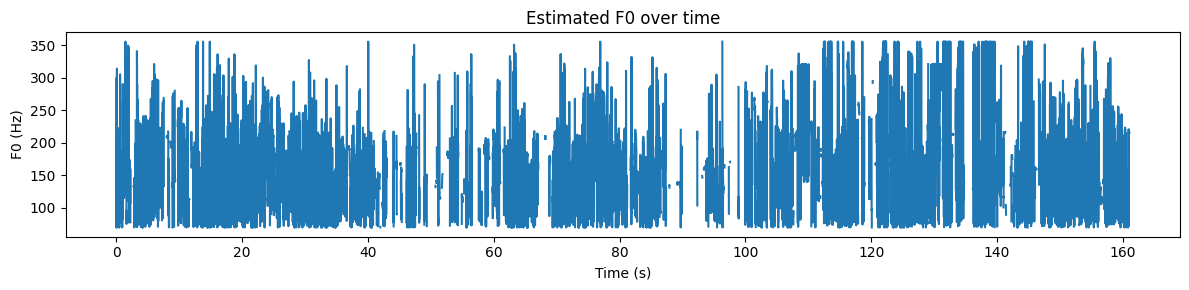

In [13]:
# ------------------ 6) 結果の可視化 ------------------
# 図1: F0(Hz) 時系列（無声は欠損）
plt.figure(figsize=(12, 3))
f0_plot = f0.copy()
f0_plot[~voiced] = np.nan
plt.plot(time, f0_plot)  # 色は指定しない（ポリシー準拠）
plt.xlabel("Time (s)")
plt.ylabel("F0 (Hz)")
plt.title("Estimated F0 over time")
plt.tight_layout()
plt.show()


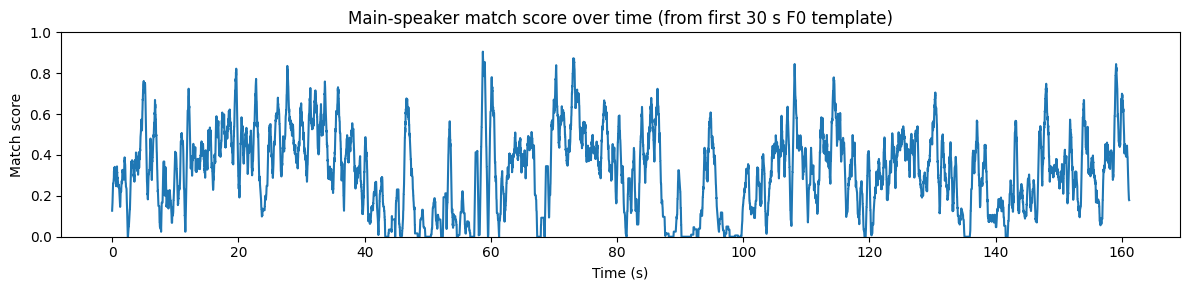

In [22]:
plt.figure(figsize=(12, 3))
plt.plot(time, score_smooth)
plt.ylim(0, 1.0)
plt.xlabel("Time (s)")
plt.ylabel("Match score")
plt.title("Main-speaker match score over time (from first 30 s F0 template)")
plt.tight_layout()
plt.show()
